Loading California Housing Dataset...

--- Dataset Preview ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

--- Model Performance Comparison ---
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732

Displaying actual vs. predicted plot window...


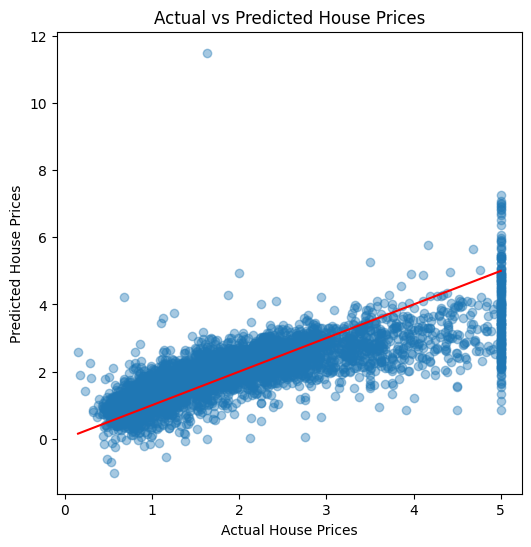

In [7]:
# ==========================================
# Step 1: Import Required Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
# Imported both legacy and modern RMSE metrics to handle library version updates safely
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    root_mean_squared_error = None
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# Step 2: Load the Dataset
# ==========================================
print("Loading California Housing Dataset...")
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("\n--- Dataset Preview ---")
print(df.head())

# ==========================================
# Step 3: Separate Features and Target Variable
# ==========================================
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# ==========================================
# Step 4: Feature Scaling (Critical Step)
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# Step 5: Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==========================================
# Step 6: Train Multiple Models
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

# ==========================================
# Step 7: Model Evaluation and Comparison
# ==========================================
results = {}

for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)
    # Predict
    predictions = model.predict(X_test)

    # Calculate RMSE cleanly depending on scikit-learn version
    if root_mean_squared_error:
        rmse = root_mean_squared_error(y_test, predictions)
    else:
        rmse = mean_squared_error(y_test, predictions, squared=False)

    # Calculate R2 Score
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Convert results dict to DataFrame, transpose for readability
results_df = pd.DataFrame(results).T
print("\n--- Model Performance Comparison ---")
print(results_df)

# ==========================================
# Step 8: Visual Performance Validation
# ==========================================
# Using Linear Regression as the 'best_model' example from instructions
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Reference line plotting
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
print("\nDisplaying actual vs. predicted plot window...")
plt.show()